In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq, ifft
from funciones import procesar

In [10]:
# Cargamos los archivos de audio
fsb, señal_b = wavfile.read('tlfn-b.wav')

# Info básica de los datos
print(f"Sample Rate: {fsb} Hz")
print(f"Data Shape: {señal_b.shape}") 

Sample Rate: 44100 Hz
Data Shape: (195000, 2)


In [11]:
# Parámetros de muestreo
Nb = len(señal_b)   #número de muestras en b
tb = np.linspace(0, Nb / fsb, Nb, endpoint=False)  # eje de tiempo (sin repetir el extremo)

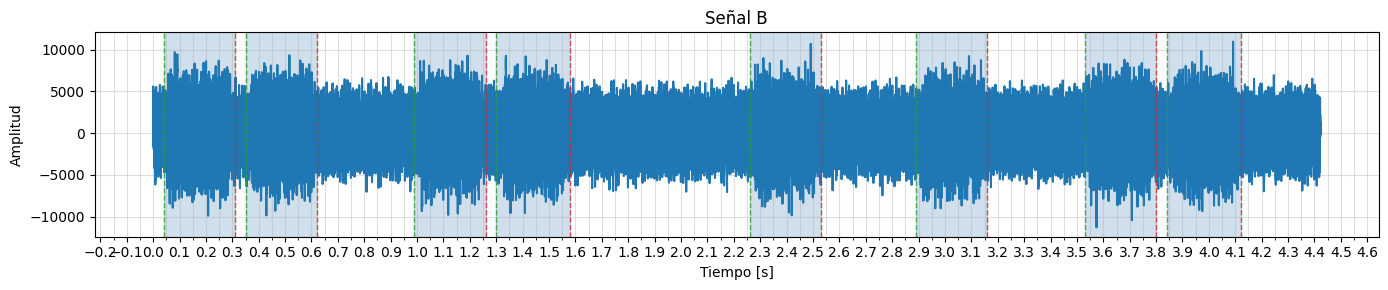

In [12]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(tb, señal_b[:, 0], zorder=2)
ax.set(xlabel="Tiempo [s]", ylabel="Amplitud", title="Señal B")
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))   # tick cada 100 ms
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))   # subtick cada 50 ms
ax.grid(True, which='both', alpha=0.4, zorder=1)

_cortes_b = [0.04, 0.31, 0.35, 0.62, 0.99, 1.26, 1.30, 1.58, 2.26, 2.53, 2.89, 3.16, 3.53, 3.80, 3.84, 4.12]
for k in range(0, len(_cortes_b), 2):
    ax.axvspan(_cortes_b[k], _cortes_b[k+1], alpha=0.25, color="steelblue", zorder=0)
# Líneas verticales en cada punto de corte (inicio en verde, fin en rojo)
for k, c in enumerate(_cortes_b):
    color = 'tab:green' if k % 2 == 0 else 'tab:red'
    ax.axvline(c, color=color, linestyle='--', alpha=0.8, linewidth=1, zorder=3)

plt.tight_layout()
plt.savefig(r'graficos\figura_9_señal_B_completa.png', dpi=120, bbox_inches='tight')
plt.show()

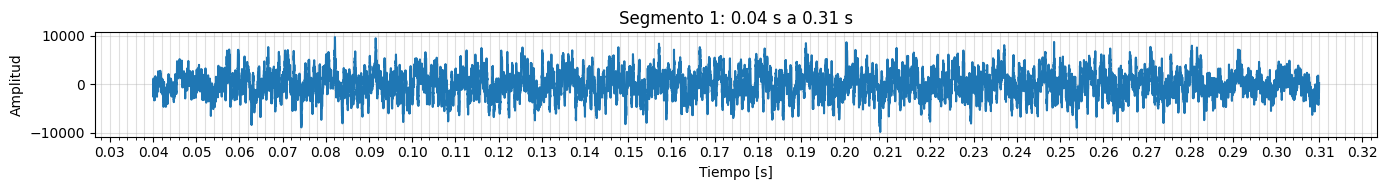

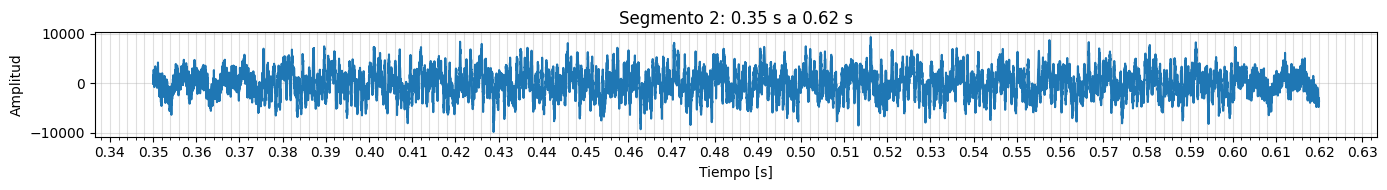

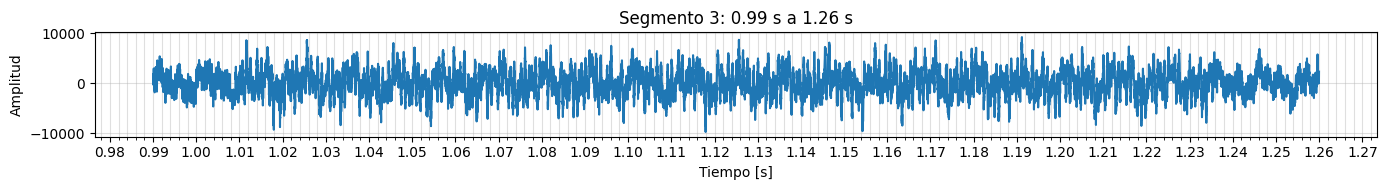

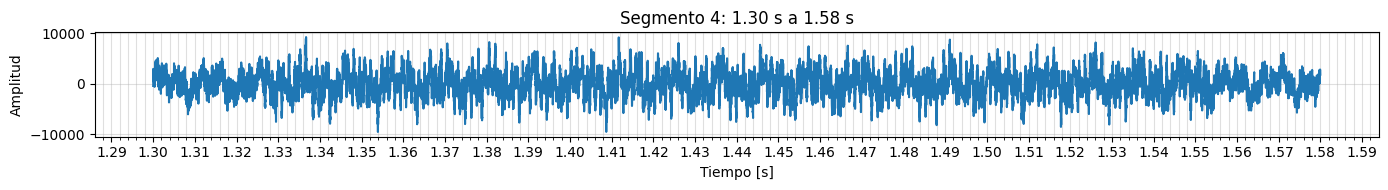

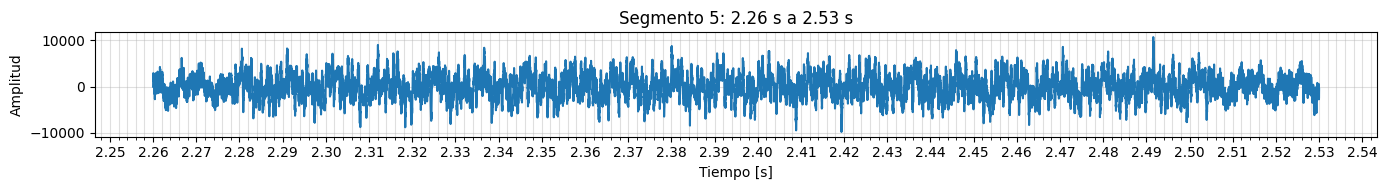

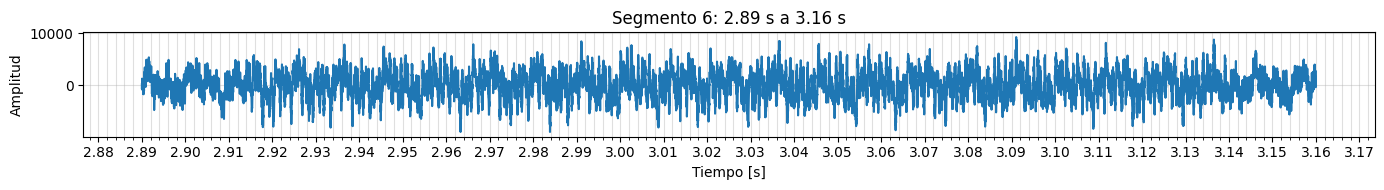

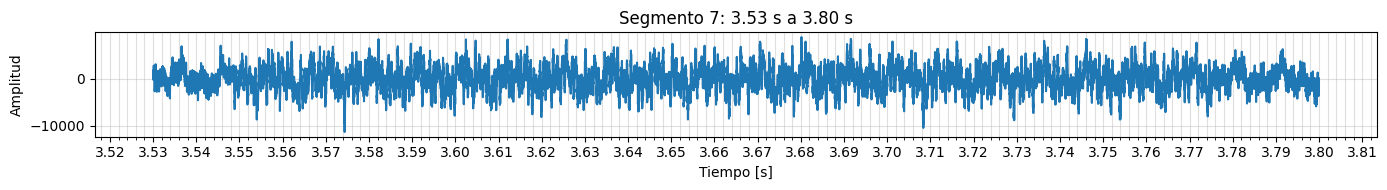

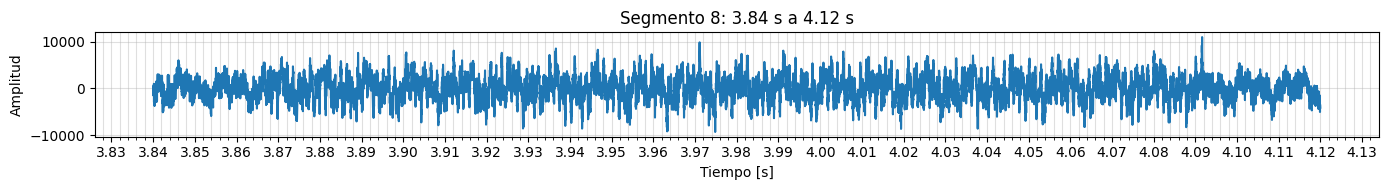

In [13]:
cortes_b = [0.04, 0.31, 0.35, 0.62, 0.99, 1.26, 1.30, 1.58, 2.26, 2.53, 2.89, 3.16, 3.53, 3.80, 3.84, 4.12]
lista_señales_b = []
#tomo de a pares los cortes para atrapar cada sonido entre cada par
for i in range(0, len(cortes_b), 2):
    inicio = cortes_b[i]
    fin = cortes_b[i+1]
    #print(f"Sonido entre {inicio:.2f} s y {fin:.2f} s")
    #partimos tb en esos intervalos
    mask = (tb >= inicio) & (tb < fin)
    segmento = señal_b[mask, 0]  # tomo solo el canal 0
    lista_señales_b.append(segmento)
    # graficar cada subseñal en su propio subplot
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.plot(tb[mask], segmento)
    ax.set(xlabel="Tiempo [s]", ylabel="Amplitud", title=f"Segmento {i//2 + 1}: {inicio:.2f} s a {fin:.2f} s")
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.01))   # tick cada 10 ms
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.002))   # subtick cada 2 ms
    ax.grid(True, which='both', alpha=0.4)
    plt.tight_layout()
    plt.show()

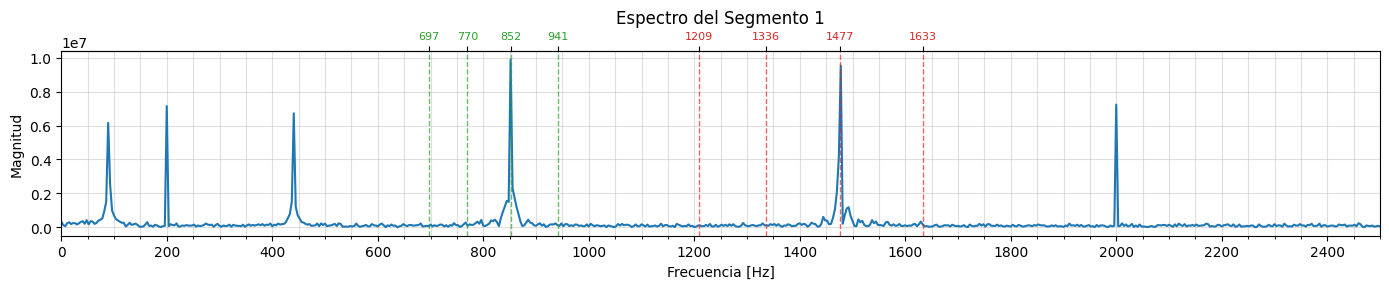

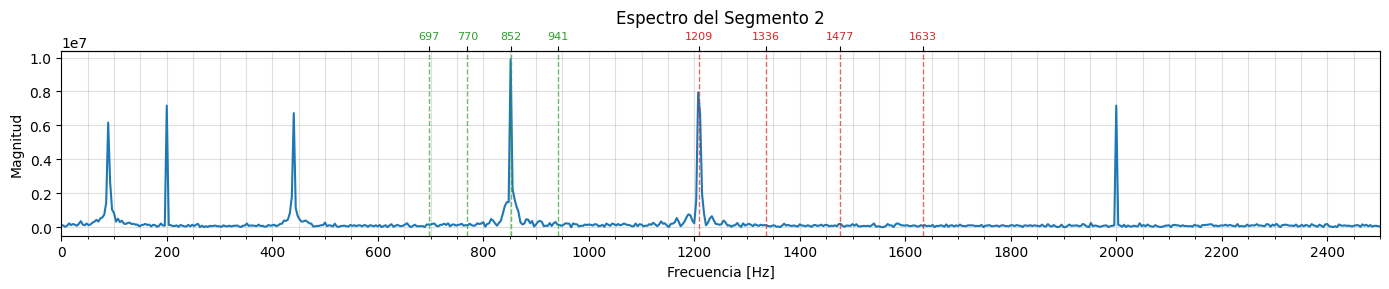

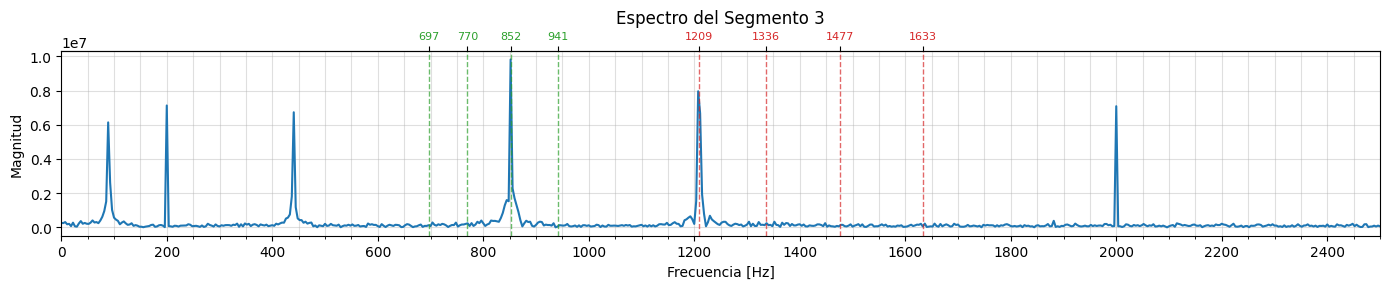

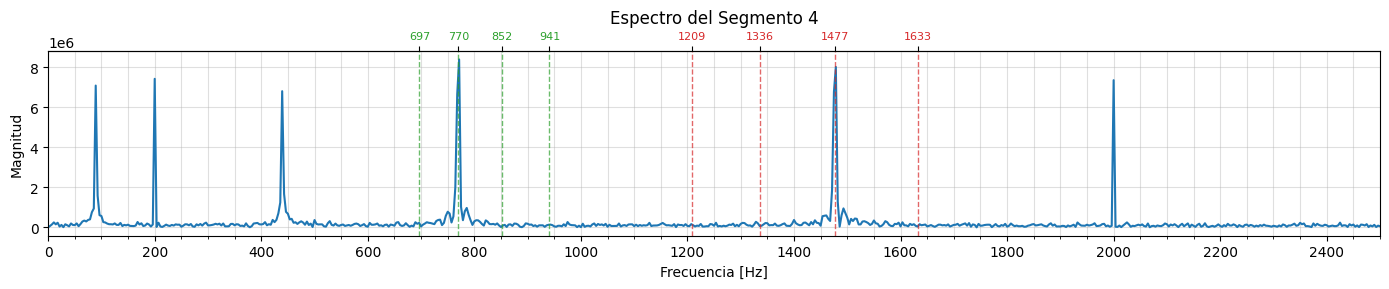

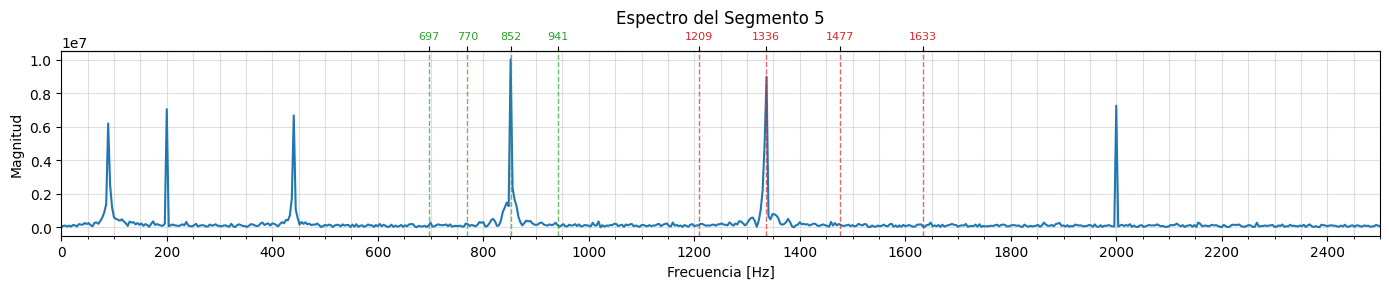

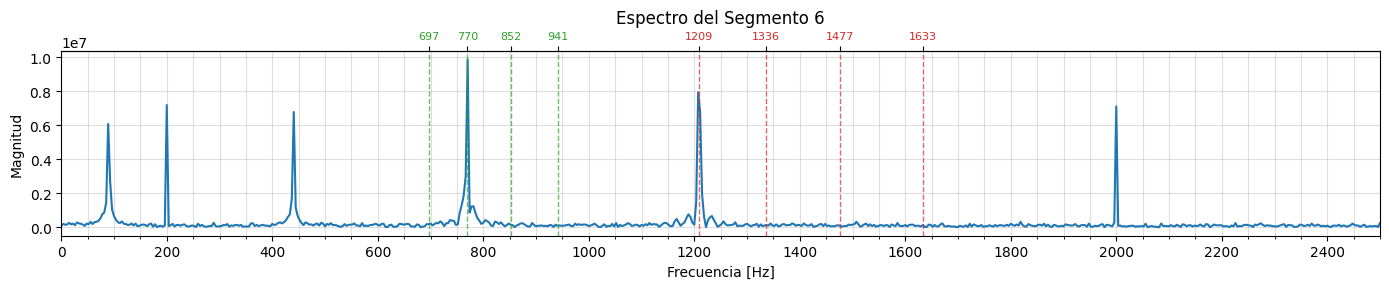

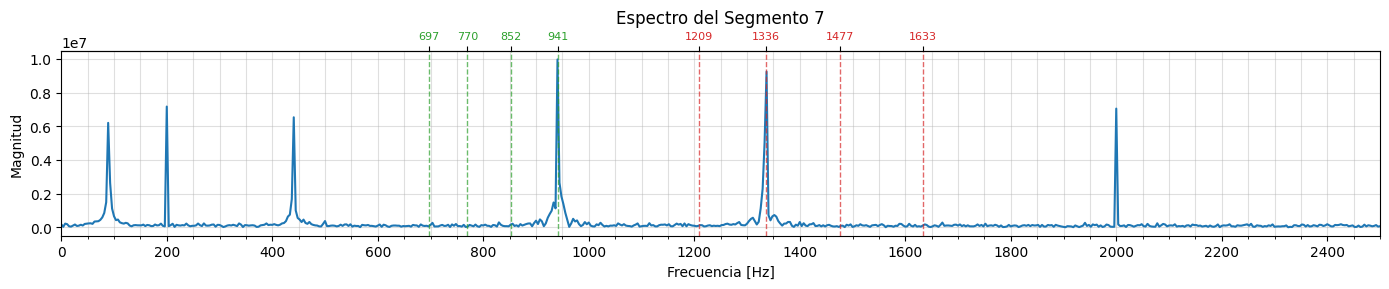

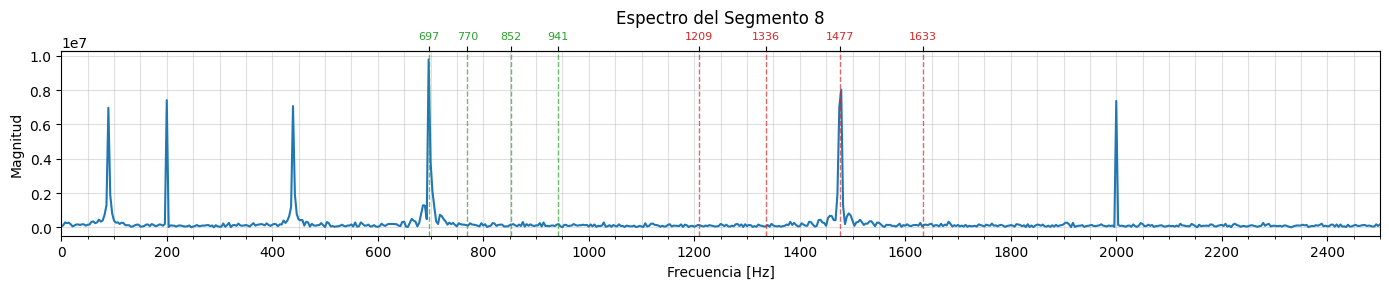

In [16]:
# Frecuencias DTMF estándar
frec_bajas_dtmf = [697, 770, 852, 941]
frec_altas_dtmf = [1209, 1336, 1477, 1633]
frec_dtmf = frec_bajas_dtmf + frec_altas_dtmf

#calculamos la FFT de cada subseñal y graficamos su espectro
for idx, segmento in enumerate(lista_señales_b):
    N = len(segmento)
    espectro = fft(segmento)
    frecuencias = fftfreq(N, d=1/fsb)
    
    # Graficar el espectro
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(frecuencias[:N//2], np.abs(espectro[:N//2]))  # solo la mitad positiva
    # Líneas verticales en las frecuencias DTMF
    for f in frec_bajas_dtmf:
        ax.axvline(f, color='tab:green', linestyle='--', alpha=0.7, linewidth=1)
    for f in frec_altas_dtmf:
        ax.axvline(f, color='tab:red', linestyle='--', alpha=0.7, linewidth=1)
    ax.set(xlabel="Frecuencia [Hz]", ylabel="Magnitud", title=f"Espectro del Segmento {idx + 1}")
    ax.set_xlim(0, 2500)  # limitar a 2500 Hz para mejor visualización
    ax.xaxis.set_major_locator(plt.MultipleLocator(200))   # tick cada 200 Hz
    ax.xaxis.set_minor_locator(plt.MultipleLocator(50))   # subtick cada 50 Hz
    ax.grid(True, which='both', alpha=0.4)
    # Eje x superior con las frecuencias DTMF etiquetadas
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(frec_dtmf)
    ax_top.set_xticklabels([str(f) for f in frec_dtmf], fontsize=8)
    for label, f in zip(ax_top.get_xticklabels(), frec_dtmf):
        label.set_color('tab:green' if f in frec_bajas_dtmf else 'tab:red')
    plt.tight_layout()
    plt.savefig(f'graficos/figura_{idx+10}_segmento_{idx+1}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [15]:
picos_b = procesar(lista_señales_b, cortes_b, fsb, 'B')

=== Señal B ===
Seg 1 [0.04-0.31 s]: f_baja = 851.9 Hz → 852 Hz  ·  f_alta = 1477.8 Hz → 1477 Hz  →  dígito 9
Seg 2 [0.35-0.62 s]: f_baja = 851.9 Hz → 852 Hz  ·  f_alta = 1207.4 Hz → 1209 Hz  →  dígito 7
Seg 3 [0.99-1.26 s]: f_baja = 851.9 Hz → 852 Hz  ·  f_alta = 1207.4 Hz → 1209 Hz  →  dígito 7
Seg 4 [1.30-1.58 s]: f_baja = 771.4 Hz → 770 Hz  ·  f_alta = 1478.6 Hz → 1477 Hz  →  dígito 6
Seg 5 [2.26-2.53 s]: f_baja = 851.9 Hz → 852 Hz  ·  f_alta = 1337.0 Hz → 1336 Hz  →  dígito 8
Seg 6 [2.89-3.16 s]: f_baja = 770.4 Hz → 770 Hz  ·  f_alta = 1207.4 Hz → 1209 Hz  →  dígito 4
Seg 7 [3.53-3.80 s]: f_baja = 940.7 Hz → 941 Hz  ·  f_alta = 1337.0 Hz → 1336 Hz  →  dígito 0
Seg 8 [3.84-4.12 s]: f_baja = 696.4 Hz → 697 Hz  ·  f_alta = 1478.6 Hz → 1477 Hz  →  dígito 3
Número B: 97768403

